In [1]:
from PIL import Image
import torch
import numpy as np
from IPython.display import clear_output
from typing import List
from tqdm import tqdm
import PIL.Image

class RePaint:
    TARGET_SIZE = (512, 512)
    def __init__(self, pipe):
        self.device = pipe.device
        self.pipe = pipe
        self.scheduler = pipe.scheduler

        self.timesteps = pipe.scheduler.timesteps
        self.betas = pipe.scheduler.betas

        self.alphas = 1 - self.betas
        self.alphas_cumprod = torch.cumprod(self.alphas, dim=0)
        self.alphas_cumprod_prev = torch.roll(self.alphas_cumprod, 1)
        self.alphas_cumprod_prev[0] = 1.0
        
        self.sqrt_one_over_alphas = torch.sqrt(1.0 / self.alphas)
        self.sqrt_one_minus_alphas_cumprod = torch.sqrt(1.0 - self.alphas_cumprod)

        self.posterior_variance = self.betas * (1. - self.alphas_cumprod_prev) / (1. - self.alphas_cumprod)

    @torch.no_grad()
    def __embed_test(self,prompt):
        text_inputs = self.pipe.tokenizer(prompt, return_tensors="pt", padding="max_length", truncation=True, max_length=pipe.tokenizer.model_max_length)
        text_embeddings = self.pipe.text_encoder(text_inputs.input_ids.to(self.device))[0]
        return text_embeddings
    
    @torch.no_grad()
    def __image_to_tensor(self, image: Image.Image) -> torch.Tensor:
        image = image.convert("RGB")
        image = image.resize(RePaint.TARGET_SIZE)

        img_tensor = torch.from_numpy(np.array(image)).float() / 127.5 - 1.0
        img_tensor = img_tensor.permute(2, 0, 1).unsqueeze(0).to(self.device, dtype=torch.float16)
    
        init_latents = self.pipe.vae.encode(img_tensor).latent_dist.sample()
        init_latents = init_latents * self.pipe.vae.config.scaling_factor

        return init_latents
    
    @torch.no_grad()
    def __mask_to_tensor(self, image: Image.Image,image_shape) -> torch.Tensor:
        image = image.convert("L")
        latent_h, latent_w = image_shape[2], image_shape[3]
        mask_resized = image.resize((latent_w, latent_h), PIL.Image.NEAREST)
    
        mask_tensor = torch.from_numpy(np.array(mask_resized)).float() / 255.0
        mask_tensor = mask_tensor.unsqueeze(0).unsqueeze(0).to(self.device, dtype=torch.float16)

        return mask_tensor

    @torch.no_grad()
    def __get_jumps(self,jumps_every:int=100, r:int=5) -> List[int]:
        jumps = []
        for i in range(0, torch.max(self.scheduler.timesteps), jumps_every):
            jumps.extend([i] * r)
        jumps.reverse()
        return jumps
    
    @torch.no_grad()
    def __single_reverse_step(self , x: torch.Tensor, t: int, text_embeddings) -> torch.Tensor:
        mean = self.sqrt_one_over_alphas[t] * (x - self.betas[t] * self.pipe.unet(x, t, encoder_hidden_states=text_embeddings).sample / self.sqrt_one_minus_alphas_cumprod[t])
        if t == 0:
            return mean
        else:
            noise = torch.randn_like(x) * torch.sqrt(self.posterior_variance[t])
            return mean + noise
        
    @torch.no_grad()
    def __zero_to_t(self,x_0: torch.Tensor, t: int) -> torch.Tensor:
        if t == 0:
            return x_0
        else:
            return torch.sqrt(self.alphas_cumprod[t]) * x_0 + \
                    torch.sqrt(1.0 - self.alphas_cumprod[t]) * torch.randn_like(x_0)

    def __tensor_to_image(self, tensor):
        final_latents = 1 / self.pipe.vae.config.scaling_factor * tensor
        image = self.pipe.vae.decode(final_latents).sample
            
        # Convert tensor to PIL Image
        image = (image / 2 + 0.5).clamp(0, 1)
        image = image.cpu().permute(0, 2, 3, 1).detach().numpy()[0]
        return PIL.Image.fromarray((image * 255).astype(np.uint8))

    @torch.no_grad()
    def __forward_j_steps(self, x_t: torch.Tensor, t: int, j: int,)-> torch.Tensor:
        partial_alpha_cumprod = self.alphas_cumprod[t+j]/self.alphas_cumprod[t]
        return torch.sqrt(partial_alpha_cumprod) * x_t + \
                torch.sqrt(1.0 - partial_alpha_cumprod) * torch.randn_like(x_t)

    def impaint(self, image: Image.Image, mask: Image.Image, prompt="", j:int=10, r:int = 5, timestamps=-1,jumps_every=50 ):
        jumps = self.__get_jumps(jumps_every=jumps_every,r=r)
        original_tensor = self.__image_to_tensor(image)
        mask_tensor = self.__mask_to_tensor(mask,original_tensor.shape)
        text_embeddings= self.__embed_test(prompt)

        sample = torch.randn_like(original_tensor).to(self.device)
        
        print("beginning impainting")
        for t in tqdm(self.scheduler.timesteps):
            while len(jumps) > 0 and jumps[0] == t:
                jumps = jumps[1:]
                sample = self.__forward_j_steps(sample, t, j)

                for override_t in range(t + j, t, -1):
                    sample = self.__single_reverse_step(sample, override_t,text_embeddings)


            x_known = self.__zero_to_t(original_tensor, t)
            x_unknown = self.__single_reverse_step(sample, t, text_embeddings)
            sample = mask_tensor * x_known + (1-mask_tensor) * x_unknown

        return self.__tensor_to_image(sample)


In [2]:
from diffusers import StableDiffusionPipeline, DDPMScheduler

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.manual_seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(42)
model_id = "sd2-community/stable-diffusion-2-base"
pipe = StableDiffusionPipeline.from_pretrained(
        model_id,
        torch_dtype=torch.float16
    ).to(device)


pipe.scheduler = DDPMScheduler.from_config(pipe.scheduler.config)
pipe.scheduler.set_timesteps(800, device=device)

Loading pipeline components...:   0%|          | 0/6 [00:00<?, ?it/s]

In [3]:
import PIL.Image
source_img = PIL.Image.open("banana.png")
# source_img.show()
mask_img = PIL.Image.open("mask_forest.png")
# mask_img.show()

In [4]:
r = RePaint(pipe)
print(r)

beginning impainting


100%|██████████| 800/800 [00:55<00:00, 14.37it/s]


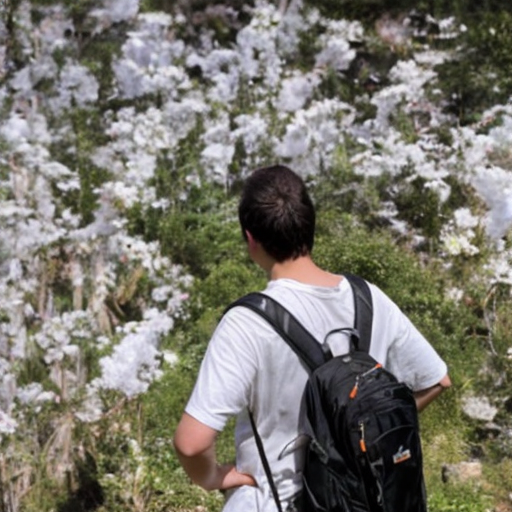

In [5]:
r.impaint(source_img,mask_img,"a picture of a bush",j=1, r=1).show()

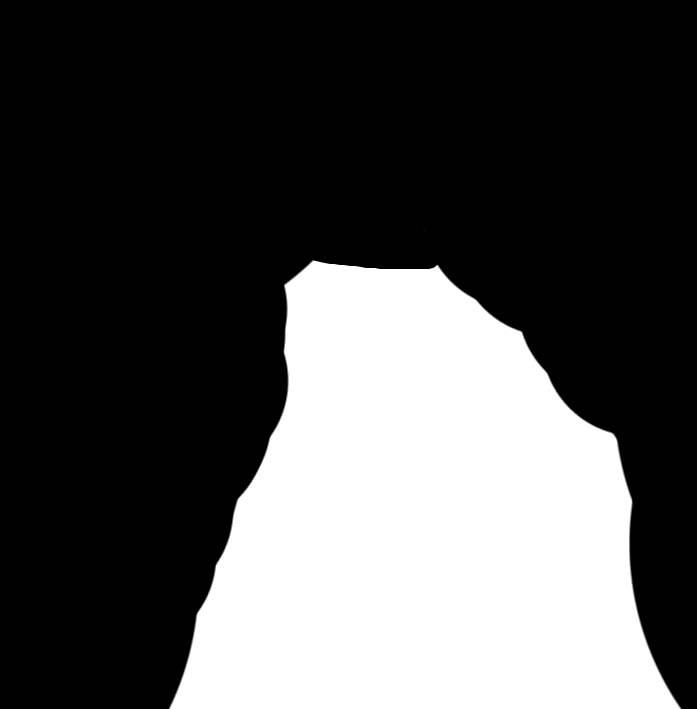

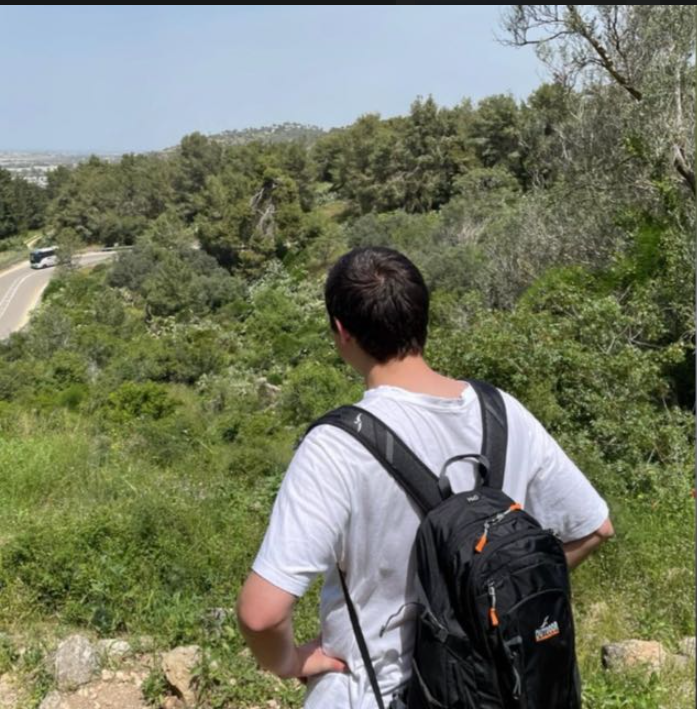

In [3]:
mask_img.show()
